# Топ тем по сложности — прототип графика для dashboard

**Задача:** подготовить график «Топ тем по сложности» для будущего модуля:

```text
dashboard/
├── app.py
├── data_loader.py
├── filters.py
├── charts/
│   ├── accuracy.py
│   ├── difficulty.py
│   ├── fast_slow.py
│   └── lectures.py
└── utils/
```

Источник для этого графика — `mart_topics.parquet`.

Логика рейтинга:
1. используем только темы с `enough_attempts = True`;
2. исключаем строки без `difficulty`;
3. сортируем по `difficulty` по убыванию;
4. при одинаковой сложности выше ставим тему с большим `attempts`;
5. показываем Top-N тем.

`difficulty = 1 - accuracy`, поэтому чем выше значение, тем сложнее тема по наблюдаемым ответам пользователей.

In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

TOP_N = 10

## 1. Поиск `mart_topics.parquet`

Ноутбук можно запускать:
- из корня проекта;
- из папки `data/`;
- рядом с самим parquet-файлом.

In [2]:
def find_mart_topics_path() -> Path:
    candidates = [
        Path("data/processed/mart_topics.parquet"),
        Path("../data/processed/mart_topics.parquet"),
        Path("../../data/processed/mart_topics.parquet"),
        Path("processed/mart_topics.parquet"),
        Path("../processed/mart_topics.parquet"),
        Path("../../processed/mart_topics.parquet"),
        Path("mart_topics.parquet"),
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Не найден mart_topics.parquet. "
        "Проверь, что файл лежит в data/processed/ или рядом с ноутбуком."
    )


MART_TOPICS_PATH = find_mart_topics_path()

print("mart_topics:", MART_TOPICS_PATH.resolve())

mart_topics: /Users/anna/проект шар/data/processed/mart_topics.parquet


## 2. Загрузка данных

Для чтения parquet используется DuckDB — тот же подход, что и в расчётных ноутбуках проекта.
После чтения дальнейшая логика работает с обычным `pandas.DataFrame`, чтобы её было легко перенести в `dashboard/charts/difficulty.py`.

In [3]:
con = duckdb.connect()

topics = con.sql(
    f"""
    SELECT *
    FROM read_parquet('{MART_TOPICS_PATH.resolve().as_posix()}')
    """
).df()

print("Размер mart_topics:", topics.shape)
display(topics.head())

Размер mart_topics: (188, 19)


,tag,questions_count,attempts,students_count,correct_answers,incorrect_answers,accuracy,difficulty,median_elapsed_time,lectures_count,lecture_views,attempts_after_lecture,accuracy_after_lecture,attempts_without_lecture,accuracy_without_lecture,accuracy_difference,enough_attempts,enough_lecture_comparison,content_gap_flag
0,0,49,326679,27343,204656,122023,0.626474,0.373526,47037.192378,2,7926,41217,0.628260,285462,0.626216,0.002044,True,True,False
1,1,422,2409509,256363,1465625,943884,0.608267,0.391733,22723.888116,4,31699,718547,0.646617,1690962,0.591971,0.054647,True,True,False
2,2,144,1727202,180466,1206072,521130,0.698281,0.301719,17000.000000,1,4808,96354,0.681383,1630848,0.699279,-0.017896,True,True,False
3,3,45,290278,27891,187107,103171,0.644579,0.355421,24299.557494,0,0,0,NaN,290278,0.644579,NaN,True,False,False
4,4,50,499255,123139,320363,178892,0.641682,0.358318,21083.910706,4,13647,86641,0.657333,412614,0.638396,0.018937,True,True,False


## 3. Проверка схемы и качества данных

Для рейтинга нужны поля:
- `tag`;
- `attempts`;
- `students_count`;
- `accuracy`;
- `difficulty`;
- `enough_attempts`.

Дополнительно оставляем несколько полей для tooltip/таблицы и дальнейшего dashboard.

In [4]:
required_columns = {
    "tag",
    "attempts",
    "students_count",
    "accuracy",
    "difficulty",
    "enough_attempts",
}

missing_columns = sorted(required_columns - set(topics.columns))
if missing_columns:
    raise ValueError(
        "В mart_topics отсутствуют необходимые столбцы: "
        + ", ".join(missing_columns)
    )

assert topics["tag"].is_unique, "Ожидалась одна строка на один tag"
assert topics["difficulty"].dropna().between(0, 1).all()
assert topics["accuracy"].dropna().between(0, 1).all()

difficulty_check = topics.loc[
    topics["accuracy"].notna() & topics["difficulty"].notna(),
    ["accuracy", "difficulty"],
].copy()

max_formula_error = (
    difficulty_check["difficulty"]
    - (1.0 - difficulty_check["accuracy"])
).abs().max()

assert max_formula_error < 1e-10

print("Тем всего:", len(topics))
print(
    "Тем с enough_attempts=True:",
    int(topics["enough_attempts"].fillna(False).sum()),
)
print(
    "Максимальная ошибка difficulty = 1 - accuracy:",
    max_formula_error,
)

Тем всего: 188
Тем с enough_attempts=True: 188
Максимальная ошибка difficulty = 1 - accuracy: 0.0


## 4. Подготовка Top-N сложных тем

Функция не читает файл сама — она получает уже загруженный DataFrame.
Это удобно для будущей архитектуры dashboard: загрузка остаётся в `data_loader.py`, а логика графика — в `charts/difficulty.py`.

In [5]:
def prepare_top_difficult_topics(
    topics_df: pd.DataFrame,
    top_n: int = 10,
) -> pd.DataFrame:
    if top_n <= 0:
        raise ValueError("top_n должен быть положительным числом")

    columns = [
        "tag",
        "questions_count",
        "attempts",
        "students_count",
        "accuracy",
        "difficulty",
        "median_elapsed_time",
        "lectures_count",
        "lecture_views",
        "content_gap_flag",
    ]

    existing_columns = [
        col for col in columns if col in topics_df.columns
    ]

    result = (
        topics_df.loc[
            topics_df["enough_attempts"].eq(True)
            & topics_df["difficulty"].notna(),
            existing_columns,
        ]
        .sort_values(
            ["difficulty", "attempts"],
            ascending=[False, False],
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return result


top_difficult_topics = prepare_top_difficult_topics(
    topics,
    top_n=TOP_N,
)

display(top_difficult_topics)

,tag,questions_count,attempts,students_count,accuracy,difficulty,median_elapsed_time,lectures_count,lecture_views,content_gap_flag
0,24,17,256613,118076,0.385725,0.614275,20698.847012,2,1870,False
1,23,11,465904,231628,0.438487,0.561513,18989.807515,2,16749,False
2,19,57,309969,170373,0.439938,0.560062,35424.385070,2,6635,False
3,151,16,537180,233727,0.493155,0.506845,17841.354922,4,13380,False
4,167,11,341067,115545,0.500432,0.499568,20327.232156,2,23218,False
5,108,20,472800,118177,0.504010,0.495990,19971.210573,2,27594,False
6,58,11,371455,120598,0.504637,0.495363,20388.602842,2,19181,False
7,50,43,804789,162917,0.506375,0.493625,31926.613273,2,3037,False
8,26,22,520203,121013,0.510045,0.489955,20269.851219,4,38777,False
9,46,10,118342,15839,0.521463,0.478537,47319.679750,0,0,False


## 5. Таблица для проверки рейтинга

Для удобства просмотра преобразуем доли в проценты только в отображаемой копии.
Исходные значения в DataFrame остаются в диапазоне `[0, 1]`.

In [6]:
top_view = top_difficult_topics.copy()

top_view["topic"] = (
    "Topic " + top_view["tag"].astype("Int64").astype(str)
)
top_view["difficulty_pct"] = (
    top_view["difficulty"] * 100
).round(2)
top_view["accuracy_pct"] = (
    top_view["accuracy"] * 100
).round(2)

display_columns = [
    "topic",
    "difficulty_pct",
    "accuracy_pct",
    "attempts",
    "students_count",
]

if "questions_count" in top_view.columns:
    display_columns.append("questions_count")

display(top_view[display_columns])

,topic,difficulty_pct,accuracy_pct,attempts,students_count,questions_count
0,Topic 24,61.43,38.57,256613,118076,17
1,Topic 23,56.15,43.85,465904,231628,11
2,Topic 19,56.01,43.99,309969,170373,57
3,Topic 151,50.68,49.32,537180,233727,16
4,Topic 167,49.96,50.04,341067,115545,11
5,Topic 108,49.60,50.40,472800,118177,20
6,Topic 58,49.54,50.46,371455,120598,11
7,Topic 50,49.36,50.64,804789,162917,43
8,Topic 26,49.00,51.00,520203,121013,22
9,Topic 46,47.85,52.15,118342,15839,10


## 6. График «Топ тем по сложности»

Горизонтальный bar chart выбран потому, что:
- рейтинг читается сверху вниз;
- идентификаторы тем не конфликтуют по ширине;
- формат удобно переносится в карточку dashboard.

На графике `difficulty` отображается в процентах.

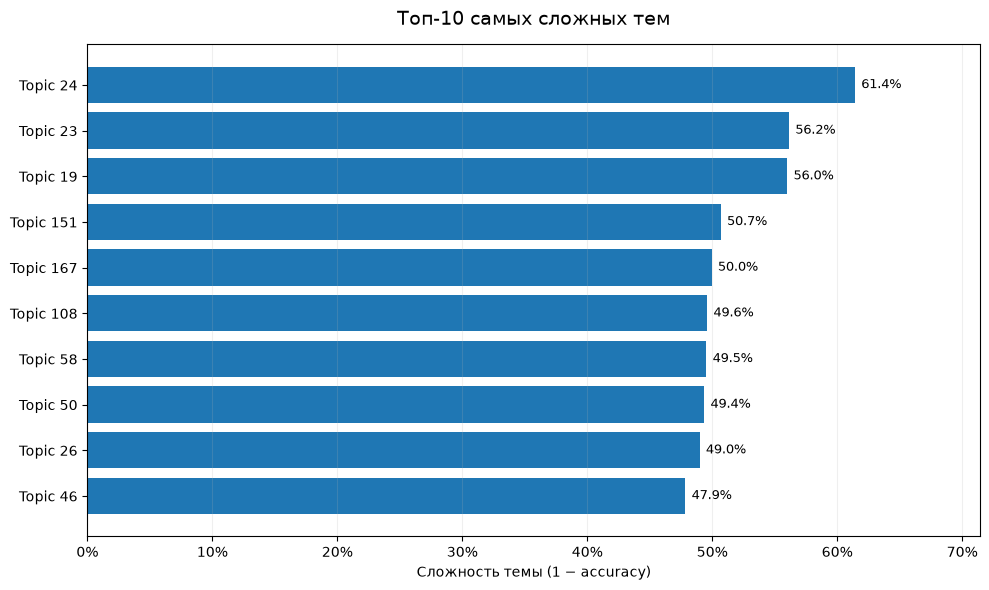

In [7]:
def plot_top_difficult_topics(
    topics_df: pd.DataFrame,
    top_n: int = 10,
    figsize=(10, 6),
):
    data = prepare_top_difficult_topics(
        topics_df=topics_df,
        top_n=top_n,
    ).copy()

    # Для barh первая строка оказывается снизу.
    # Поэтому сортируем по возрастанию, чтобы самая
    # сложная тема визуально оказалась сверху.
    plot_data = data.sort_values(
        ["difficulty", "attempts"],
        ascending=[True, True],
    ).copy()

    plot_data["topic_label"] = (
        "Topic "
        + plot_data["tag"].astype("Int64").astype(str)
    )

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.barh(
        plot_data["topic_label"],
        plot_data["difficulty"],
    )

    ax.set_title(
        f"Топ-{len(plot_data)} самых сложных тем",
        fontsize=14,
        pad=14,
    )
    ax.set_xlabel("Сложность темы (1 − accuracy)")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="x", alpha=0.2)

    for bar, value in zip(
        bars,
        plot_data["difficulty"],
    ):
        ax.text(
            value + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1%}",
            va="center",
            fontsize=9,
        )

    max_value = plot_data["difficulty"].max()
    ax.set_xlim(
        0,
        min(1.0, max_value + 0.10),
    )

    fig.tight_layout()
    return fig


fig = plot_top_difficult_topics(
    topics,
    top_n=TOP_N,
)

plt.show()

## 7. Данные, которые стоит показывать в dashboard

Для самого графика достаточно:
- `tag`;
- `difficulty`.

Для tooltip или подписи при наведении полезны:
- `accuracy`;
- `attempts`;
- `students_count`;
- `questions_count`;
- `lectures_count`;
- `content_gap_flag`.

В текущей витрине нет текстового справочника `tag → название темы`, поэтому безопасная подпись — `Topic <tag>`.
Если позже появится справочник названий тем, его можно присоединить до построения графика.

## 8. Код для будущего `dashboard/charts/difficulty.py`

В модуль графика можно перенести две функции из ноутбука:

```python
prepare_top_difficult_topics(...)
plot_top_difficult_topics(...)
```

Рекомендуемое разделение ответственности:

```text
data_loader.py
    └── загружает mart_topics.parquet

charts/difficulty.py
    ├── prepare_top_difficult_topics(topics_df, top_n)
    └── plot_top_difficult_topics(topics_df, top_n)

app.py
    └── получает данные из loader и отображает figure
```

Важно: рейтинг строится только по `enough_attempts = True`, чтобы темы с маленькой выборкой не попадали в Top сложных.